# Table of Contents
- [Data Cleaning: Listings.csv & Neighbourhood geoJSON](#data-cleaning-listingscsv--neighbourhood-geojson)
  - [Mapping](#mapping)
  - [Data Cleaning](#data-cleaning)
- [Host Clustering](#host-clustering)
- [Additonal Data Cleaning: Calendar.csv](#additonal-data-cleaning-calendarcsv)
- [Price Exploration](#price-exploration)
- [Add attractions table](#add-attractions-table)
- [Amenitites Count](#amenitites-count)

## Data Cleaning: Listings.csv & Neighbourhood geoJSON

Source: https://insideairbnb.com/get-the-data; Date Range: March 2025 - Mid March 2026

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd
import re
import ast
import datetime

In [2]:
# Load the listings data
listings = pd.read_csv("/Users/franziskameyndt/Desktop/Airbnb Projekt/listings.csv")

In [3]:
# Check empty values
print(listings.isna().sum()[listings.isna().sum() > 0])

description                      2905
neighborhood_overview           43553
picture_url                         1
host_name                          41
host_since                         41
host_location                   17162
host_about                      48374
host_response_time              35849
host_response_rate              35849
host_acceptance_rate            27609
host_is_superhost                1998
host_thumbnail_url                 41
host_picture_url                   41
host_neighbourhood              56247
host_listings_count                41
host_total_listings_count          41
host_verifications                 41
host_has_profile_pic               41
host_identity_verified             41
neighbourhood                   43553
neighbourhood_group_cleansed    86064
bathrooms                       30153
bathrooms_text                     73
bedrooms                         7124
beds                            30392
price                           30409
minimum_mini

In [4]:
# Check in percentage
missing = listings.isna().sum()
missing_percent = (missing / len(listings)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

neighbourhood_group_cleansed    100.000000
calendar_updated                100.000000
host_neighbourhood               65.354852
host_about                       56.207009
neighbourhood                    50.605363
neighborhood_overview            50.605363
host_response_time               41.653885
host_response_rate               41.653885
price                            35.333008
estimated_revenue_l365d          35.333008
beds                             35.313255
bathrooms                        35.035555
host_acceptance_rate             32.079615
review_scores_checkin            25.345092
review_scores_value              25.345092
review_scores_location           25.343930
review_scores_accuracy           25.336959
review_scores_communication      25.334635
review_scores_cleanliness        25.333473
first_review                     25.323015
last_review                      25.323015
review_scores_rating             25.323015
reviews_per_month                25.323015
license    

### Mapping

In [5]:
#pip install geopandas

In [6]:
# Convert listings to GeoDataFrame
listings["geometry"] = listings.apply(lambda row: Point(row["longitude"], row["latitude"]), axis=1)
listings_gdf = gpd.GeoDataFrame(listings, geometry="geometry", crs="EPSG:4326")

# Load GeoJSON
neighbourhoods_geo = gpd.read_file("neighbourhoods.geojson")

# Spatial join
enriched_listings = gpd.sjoin(listings_gdf, neighbourhoods_geo, how="left", predicate="within")

# Rename the joined fields to match Airbnb logic
enriched_listings = enriched_listings.rename(columns={
    "neighbourhood": "neighbourhood_cleansed",
    "neighbourhood_group": "neighbourhood_group_cleansed"
})

In [7]:
# Check for missing values in columns
print(enriched_listings["neighbourhood_cleansed"].isna().sum())
print(enriched_listings["neighbourhood_group_cleansed"].isna().sum())

0
neighbourhood_group_cleansed    86064
neighbourhood_group_cleansed    86064
dtype: int64


In [8]:
# Assign Paris region based on latitude and longitude
def assign_paris_region(lat, lon):
    # Define central Paris roughly around the 1st to 4th arrondissements
    if 48.84 <= lat <= 48.87 and 2.33 <= lon <= 2.38:
        return "Paris Centre"
    elif lat > 48.87:
        return "Paris North"
    elif lat < 48.84:
        return "Paris South"
    elif lon < 2.33:
        return "Paris West"
    elif lon > 2.38:
        return "Paris East"
    else:
        return "Undefined"

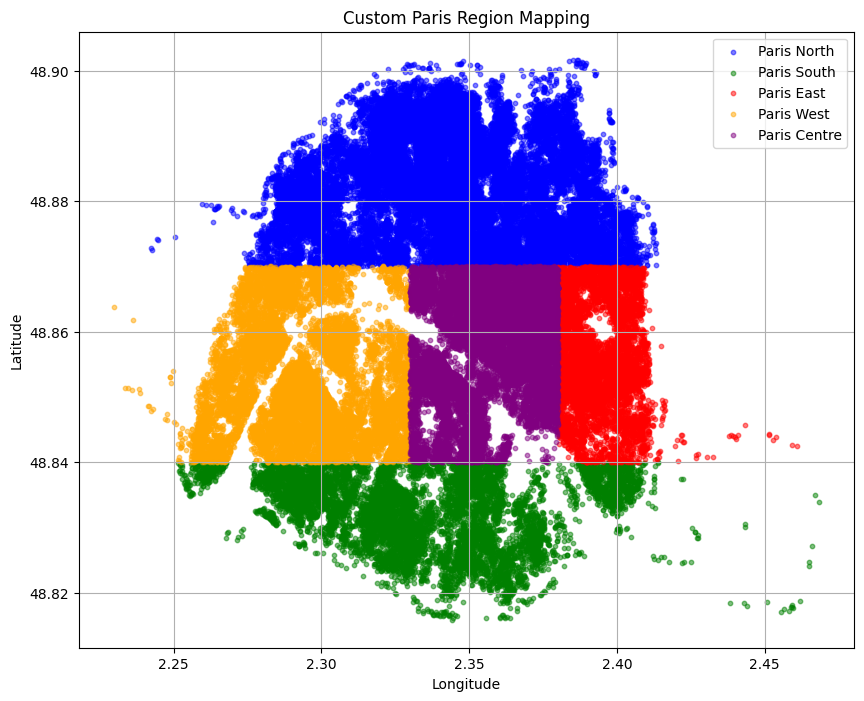

In [9]:
# Remove duplicate columns
enriched_listings = enriched_listings.loc[:, ~enriched_listings.columns.duplicated()]

# Apply the region assignment
enriched_listings["neighbourhood_group_cleansed"] = enriched_listings.apply(
    lambda row: assign_paris_region(row["latitude"], row["longitude"]), axis=1
)

# Define custom colors for regions
colors = {
    "Paris North": "blue",
    "Paris South": "green",
    "Paris East": "red",
    "Paris West": "orange",
    "Paris Centre": "purple"
}

# Plot the listings by region
fig, ax = plt.subplots(figsize=(10, 8))

for region, color in colors.items():
    subset = enriched_listings[enriched_listings["neighbourhood_group_cleansed"] == region]
    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        label=region,
        alpha=0.5,
        c=color,
        s=10
    )

plt.legend()
plt.title("Custom Paris Region Mapping")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [10]:
# Apply the region assignment to the listings
enriched_listings["neighbourhood_group_cleansed"] = enriched_listings.apply(
    lambda row: assign_paris_region(row["latitude"], row["longitude"]), axis=1
)

In [11]:
# Check for missing values after assignment
print(enriched_listings["neighbourhood_group_cleansed"].isna().sum())

0


_______

### Data Cleaning

In [12]:
# Check for missing values in percentage again
missing = enriched_listings.isna().sum()
missing_percent = (missing / len(enriched_listings)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

calendar_updated               100.000000
host_neighbourhood              65.354852
host_about                      56.207009
neighborhood_overview           50.605363
neighbourhood_left              50.605363
host_response_time              41.653885
host_response_rate              41.653885
price                           35.333008
estimated_revenue_l365d         35.333008
beds                            35.313255
bathrooms                       35.035555
host_acceptance_rate            32.079615
review_scores_checkin           25.345092
review_scores_value             25.345092
review_scores_location          25.343930
review_scores_accuracy          25.336959
review_scores_communication     25.334635
review_scores_cleanliness       25.333473
review_scores_rating            25.323015
last_review                     25.323015
first_review                    25.323015
reviews_per_month               25.323015
license                         20.935583
host_location                   19

Fill 'unknown' for host_verifications

In [13]:
# Fill string or object columns with "Unknown"
unknown_fill_cols = [
    "host_verifications",     # list-like (will become object)
]

for col in unknown_fill_cols:
    enriched_listings[col] = enriched_listings[col].fillna("Unknown")

Defining a categorical dtype with an ordered list of response times

In [14]:
# Define the ordered categorical type
response_type = pd.CategoricalDtype(
    ['Unknown', 'within an hour', 'within a few hours', 'within a day', 'a few days or more'],
    ordered=True
)

# Fill missing values with 'Unknown'
enriched_listings["host_response_time"] = enriched_listings["host_response_time"].fillna("Unknown")

# Convert to categorical with specified order
enriched_listings["host_response_time"] = enriched_listings["host_response_time"].astype(response_type)

Clean for host_response_rate and host_acceptance_rate

In [15]:
# Clean and convert percentage columns
def clean_percentage(val):
    if isinstance(val, str) and val.endswith('%'):
        return float(val.strip('%')) / 100
    return np.nan

enriched_listings["host_response_rate_clean"] = enriched_listings["host_response_rate"].apply(clean_percentage)
enriched_listings["host_acceptance_rate_clean"] = enriched_listings["host_acceptance_rate"].apply(clean_percentage)

Fill "No Description" for missing description

In [16]:
# Fill string or object columns with "Unknown"
no_desc_fill_cols = [
    "description",     # string
]

for col in no_desc_fill_cols:
    enriched_listings[col] = enriched_listings[col].fillna("No Description")

For no reviews, fill for the others 0 and for date NaT

In [17]:
def fill_no_reviews_data(df):
    """
    For listings with number_of_reviews == 0, fill:
    - review scores with 0
    - reviews_per_month with 0
    - first_review and last_review with pd.NaT
    """
    # Define condition
    no_reviews = df["number_of_reviews"] == 0

    # Define columns to fill with 0
    score_columns = [
        "review_scores_value",
        "review_scores_checkin",
        "review_scores_location",
        "review_scores_accuracy",
        "review_scores_communication",
        "review_scores_cleanliness",
        "review_scores_rating",
        "reviews_per_month"
    ]

    # Set score and review count columns to 0
    df.loc[no_reviews, score_columns] = 0

    # Set date columns to NaT
    df.loc[no_reviews, "first_review"] = pd.NaT
    df.loc[no_reviews, "last_review"] = pd.NaT

    return df

In [18]:
# Apply the function to fill no reviews data
enriched_listings = fill_no_reviews_data(enriched_listings)

Import Bathroom text numbers to bathrooms integer column

In [19]:
# Function to extract numeric bathroom count, including "Half-bath" cases
def extract_bathroom_number(text):
    try:
        if pd.isna(text):
            return np.nan
        if "Half-bath" in text:
            return 0.5
        return float(text.split()[0])
    except:
        return np.nan

# Apply function to extract bathroom number from text
enriched_listings["bathrooms_text_num"] = enriched_listings["bathrooms_text"].apply(extract_bathroom_number)

# Fill missing values in 'bathrooms' from extracted values
enriched_listings["bathrooms"] = enriched_listings["bathrooms"].fillna(enriched_listings["bathrooms_text_num"])

# Drop helper column
enriched_listings.drop(columns=["bathrooms_text_num"], inplace=True)

Manual exclusion of columns

In [20]:
# Drop columns that are not relevant for analysis
enriched_listings.drop(columns=[
    'calendar_updated',# empty values;not relevant, calendar.csv contains the calendar data
    'host_about', # host_about = Host's description; not relevant for analysis; Drop (free-text, not reliable for modeling)
    'neighborhood_overview', #neighborhood_overview = Host's description of the neighbourhood; Drop (free-text, optional for descriptions)
    'neighbourhood_left', # not relevant, drop
    'host_neighbourhood', # not relevant, drop
    'listing_url',
    'scrape_id',
    'last_scraped',
    'source',
    'host_url',
    'host_location',
    'host_listings_count',
    'host_total_listings_count',
    'property_type',
    'bathrooms_text',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'calendar_last_scraped',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    'first_review',
    'calendar_last_scraped',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'host_name',
    'host_thumbnail_url',
    'picture_url',
    'index_right',
    'neighbourhood_right',
    "host_has_profile_pic",
    "host_picture_url",
], inplace=True)

Check minimum nights distribution

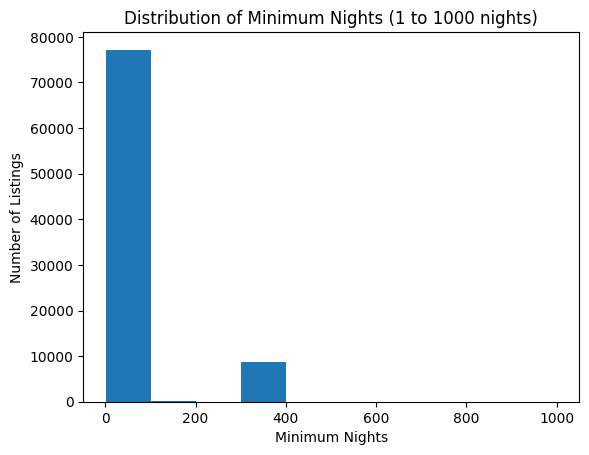

In [21]:
# Plot the distribution of minimum nights
plt.hist(enriched_listings["minimum_nights"], bins=10, range=(1, 1000))
plt.title("Distribution of Minimum Nights (1 to 1000 nights)")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.show()

In [22]:
# Print quantiles for minimum nights
print(enriched_listings["minimum_nights"].quantile([0.75, 0.89, 0.95, 0.99]))

0.75      6.0
0.89     90.0
0.95    365.0
0.99    365.0
Name: minimum_nights, dtype: float64


In [23]:
# Print the number of enriched listings
print(len(enriched_listings))

86064


In [24]:
# Print the number of listings with minimum nights greater than 90
print((enriched_listings["minimum_nights"] > 90).sum())

9019


Despite the high amount of data that would be lost, from a business perspective it would not make sense to look at any listings which would entail minimum nights above 90 days = 3 months

Cap minimum nigths and create additional column 'is_long_term_only' boolean, transform boolean for license, host_is_superhost, instant_bookable, has_availability, host_identity_verified

Convert host_response_rate and host_acceptance_rate to float -> %

Ensure price & datetime are the correct data type

In [25]:
# Create 'minimum_nights_capped' and drop listings with minimum_nights > 90
enriched_listings = enriched_listings[enriched_listings["minimum_nights"] <= 90].copy()
enriched_listings["minimum_nights_capped"] = enriched_listings["minimum_nights"].clip(upper=90)

# Convert 'license' to boolean (True if present/non-empty string, else False — no NA)
enriched_listings["license_online_available_bool"] = enriched_listings["license"].apply(
    lambda x: bool(str(x).strip()) if pd.notnull(x) else False
)

# Convert boolean-like string columns to boolean (t/true = True, f/false = False, else NA)
bool_cols = ["host_is_superhost", "instant_bookable", "has_availability", "host_identity_verified"]
for col in bool_cols:
    enriched_listings[col + "_bool"] = enriched_listings[col].apply(
        lambda x: True if str(x).strip().lower() in ["t", "true"] else (
            False if str(x).strip().lower() in ["f", "false"] else pd.NA
        )
    )

# Create 'is_long_term_only': True if minimum_nights_capped >= 30, else False
enriched_listings["is_long_term_only"] = enriched_listings["minimum_nights_capped"].apply(
    lambda x: True if x >= 30 else False
)

# Convert host_response_rate and host_acceptance_rate to float (0–1)
def percent_to_float(x):
    if pd.isnull(x):
        return pd.NA
    x = str(x).strip().replace("%", "")
    try:
        return float(x) / 100
    except:
        return pd.NA

enriched_listings["host_response_rate_clean"] = enriched_listings["host_response_rate"].apply(percent_to_float)
enriched_listings["host_acceptance_rate_clean"] = enriched_listings["host_acceptance_rate"].apply(percent_to_float)

# Clean and convert price to numeric
enriched_listings["price"] = enriched_listings["price"].replace(r'[\$,]', '', regex=True)
enriched_listings["price"] = pd.to_numeric(enriched_listings["price"], errors='coerce')

# Convert date columns to datetime
date_cols = ["host_since", "last_review"]
for col in date_cols:
    enriched_listings[col] = pd.to_datetime(enriched_listings[col], errors='coerce')

# Ensure bool columns use 'boolean' dtype
bool_cols_final = [
    "license_online_available_bool",
    "host_is_superhost_bool",
    "instant_bookable_bool",
    "has_availability_bool",
    "host_identity_verified_bool",
    "is_long_term_only"
]

for col in bool_cols_final:
    enriched_listings[col] = enriched_listings[col].astype("boolean")

# Drop original columns
drop_cols = ["license", "host_is_superhost", "instant_bookable", "has_availability", "host_identity_verified", "minimum_nights", "host_response_rate", "host_acceptance_rate"]
enriched_listings.drop(columns=drop_cols, inplace=True, errors='ignore')

Categorize room_type

In [26]:
# Check unique values in 'room_type'
print(enriched_listings["room_type"].unique())

['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']


In [27]:
# Define the order for 'room_type' and convert to categorical
room_type_order = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]
enriched_listings["room_type"] = pd.Categorical(
    enriched_listings["room_type"],
    categories=room_type_order,
    ordered=True
)

In [28]:
# Convert 'room_type' to categorical type
enriched_listings["room_type"] = enriched_listings["room_type"].astype("category")

Check host_verfifcations

In [29]:
# Check unique values in 'host_verifications'
print(enriched_listings["host_verifications"].unique())

["['email', 'phone']" "['phone']" "['email', 'phone', 'work_email']" '[]'
 "['email']" 'Unknown' "['phone', 'work_email']" "['email', 'work_email']"
 "['email', 'phone', 'photographer']" "['work_email']"]


In [30]:
# Clean 'host_verifications' column
# Safely parse and clean host_verifications
def clean_verifications(val):
    try:
        parsed = ast.literal_eval(val) if pd.notnull(val) else []
        if not isinstance(parsed, list):
            return []
        return [v for v in parsed if v in {"email", "phone", "work_email"}]
    except:
        return []

# Apply cleaning
enriched_listings["host_verifications_clean"] = enriched_listings["host_verifications"].apply(clean_verifications)

# Convert to string — show "unknown" if list is empty
enriched_listings["host_verifications_cleaned"] = enriched_listings["host_verifications_clean"].apply(
    lambda x: ",".join(x) if x else "unknown"
)

# Drop original + intermediate list column
if "host_verifications" in enriched_listings.columns and "host_verifications_clean" in enriched_listings.columns:
    enriched_listings.drop(columns=["host_verifications", "host_verifications_clean"], inplace=True)

Check final data types

In [31]:
# Display the final enriched listings DataFrame info
enriched_listings.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 77045 entries, 0 to 86063
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              77045 non-null  int64         
 1   name                            77045 non-null  object        
 2   description                     77045 non-null  object        
 3   host_id                         77045 non-null  int64         
 4   host_since                      77011 non-null  datetime64[ns]
 5   host_response_time              77045 non-null  category      
 6   neighbourhood_cleansed          77045 non-null  object        
 7   neighbourhood_group_cleansed    77045 non-null  object        
 8   latitude                        77045 non-null  float64       
 9   longitude                       77045 non-null  float64       
 10  room_type                       77045 non-null  category      
 11 

In [32]:
#save the enriched listings to a new CSV file
enriched_listings.to_csv("enriched_listings.csv", index=False)

In [33]:
# Check for missing values in percentage the enriched listings
missing = enriched_listings.isna().sum()
missing_percent = (missing / len(enriched_listings)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

host_response_rate_clean       35.506522
price                          28.854566
beds                           28.824713
host_acceptance_rate_clean     24.907522
last_review                    23.507041
bedrooms                        6.428710
has_availability_bool           3.843209
host_is_superhost_bool          2.542670
bathrooms                       0.090856
host_since                      0.044130
host_identity_verified_bool     0.044130
review_scores_checkin           0.011681
review_scores_value             0.010384
review_scores_location          0.010384
review_scores_accuracy          0.010384
review_scores_cleanliness       0.009086
review_scores_communication     0.006490
dtype: float64


Host active years

In [34]:
# Convert host_since to datetime
enriched_listings['host_since'] = pd.to_datetime(enriched_listings['host_since'], errors='coerce')

# Calculate active years from host_since to today
today = pd.to_datetime(datetime.datetime.today())
enriched_listings['host_active_years'] = (today - enriched_listings['host_since']).dt.days // 365


Host Listings Count

In [35]:
# Count how many listings each host has
host_listings_count = enriched_listings.groupby('host_id')['id'].nunique().reset_index()

# Rename column
host_listings_count.rename(columns={'id': 'host_listings_count'}, inplace=True)

# Merge back into original DataFrame (if needed)
enriched_listings = enriched_listings.merge(host_listings_count, on='host_id', how='left')


In [36]:
#pip install scikit-learn

In [37]:
# Remove duplicate listings based on '
enriched_listings = enriched_listings.drop_duplicates(subset="id")

In [38]:
# Print the number of enriched listings
print("Anzahl Zeilen in enriched_listings:", len(enriched_listings))

Anzahl Zeilen in enriched_listings: 77045


Save as xlsx file and ensure that illegal characters are removed -> cleaned df

In [39]:
# Define a function to remove illegal Excel characters
def remove_illegal_excel_chars(val):
	if isinstance(val, str):
		# Remove ASCII control characters except for tab (\x09), line feed (\x0A), and carriage return (\x0D)
		return re.sub(r"[\x00-\x08\x0B\x0C\x0E-\x1F]", "", val)
	return val

# Apply to all object columns
for col in enriched_listings.select_dtypes(include="object").columns:
	enriched_listings[col] = enriched_listings[col].apply(remove_illegal_excel_chars)

enriched_listings.to_excel("enriched_listings.xlsx", index=False)

In [40]:
# Load the calendar data
calendar = pd.read_csv("/Users/franziskameyndt/Desktop/Airbnb Projekt/calendar.csv")

/var/folders/6g/cgk7pdpx0g17h3bnvmtchtt80000gn/T/ipykernel_4751/1900789920.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  calendar = pd.read_csv("/Users/franziskameyndt/Desktop/Airbnb Projekt/calendar.csv")


In [41]:
# Convert 'date' to datetime
calendar["date"] = pd.to_datetime(calendar["date"])

# Change adjusted_price to numeric
calendar["adjusted_price"] = calendar["adjusted_price"].replace(r'[\$,]', '', regex=True).astype(float)

# Filter calendar for the specific date (4th March 2025)
target_date = pd.to_datetime("2025-03-04")
calendar_filtered = calendar[calendar["date"] == target_date][["listing_id", "adjusted_price"]]
calendar_filtered.rename(columns={"adjusted_price": "price_2025_03_04"}, inplace=True)

# Merge listings with calendar_filtered
enriched_listings = enriched_listings.merge(calendar_filtered, left_on="id", right_on="listing_id", how="left")

# Override 'price' in listings with the value from 4th March 2025, if available
enriched_listings["price"] = enriched_listings["price_2025_03_04"].combine_first(enriched_listings["price"])

# Remove helper columns
enriched_listings.drop(columns=["listing_id", "price_2025_03_04"], inplace=True)

# Save
enriched_listings.to_excel("enriched_listings_with_price_2025_03_04.xlsx", index=False)

______

## Host Clustering

host_active_years                34
log_listings                      0
host_response_rate_clean      27356
host_acceptance_rate_clean    19190
dtype: int64


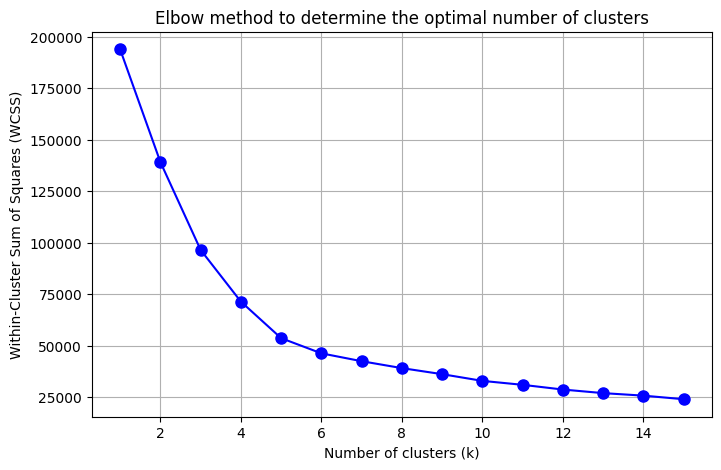

Cluster centers (scaled values):
[[-0.25470585  1.78795228  0.18305794  0.42439224]
 [ 0.73895298 -0.50182752  0.2423155  -0.09442409]
 [ 0.10825961 -0.56848732 -3.57495935 -2.17439188]
 [-1.11527653 -0.26435926  0.21591726  0.32845043]]

Number of data points per cluster:
cluster
1.0    22955
3.0    13358
0.0     9321
2.0     2840
Name: count, dtype: int64


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering !
features = ['host_active_years', 'host_listings_count', 'host_response_rate_clean']

# Log-Transformation due to skewness
enriched_listings['log_listings'] = np.log1p(enriched_listings['host_listings_count'])

# Feature-Matrix
X = enriched_listings[['host_active_years', 'log_listings', 'host_response_rate_clean', 'host_acceptance_rate_clean']].copy()

# Check for missing values
print(X.isnull().sum())

# Remove missing values (rows with NaN)
X_clean = X.dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Elbow method (k=1 until 15)
wcss = []
K_range = range(1, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow method to determine the optimal number of clusters')
plt.grid(True)
plt.show()

# K-Means with optimal k -> this got changed based on the elbow plot
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)

# Cluster the data
clusters = kmeans_final.fit_predict(X_scaled)

# Clustter definition in the original DataFrame
enriched_listings.loc[X_clean.index, 'cluster'] = clusters

# Cluster centers
print("Cluster centers (scaled values):")
print(kmeans_final.cluster_centers_)

# Cluster sizes
print("\nNumber of data points per cluster:")
print(enriched_listings['cluster'].value_counts())

# For Power BI export, select relevant columns
cols_for_powerbi = ['host_id', 'host_active_years', 'host_listings_count', 'host_response_rate_clean', 'host_acceptance_rate_clean', 'cluster']

# Ensure all columns exist
cols_for_powerbi = [col for col in cols_for_powerbi if col in enriched_listings.columns]

# Export to CSV without index
enriched_listings[cols_for_powerbi].to_csv("clustered_hosts_powerbi.csv", index=False)

In [43]:
# Show unique cluster IDs and their count
unique_clusters = enriched_listings['cluster'].dropna().unique()
print("Eindeutige Cluster-IDs:", unique_clusters)
print("Anzahl eindeutiger Cluster:", len(unique_clusters))

Eindeutige Cluster-IDs: [1. 2. 3. 0.]
Anzahl eindeutiger Cluster: 4


______

## Additonal Data Cleaning: Calendar.csv

Source: https://insideairbnb.com/get-the-data; Date Range: March 2025 - Mid March 2026 

In [44]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31442697 entries, 0 to 31442696
Data columns (total 7 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[ns]
 2   available       object        
 3   price           object        
 4   adjusted_price  float64       
 5   minimum_nights  float64       
 6   maximum_nights  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 1.6+ GB


<Axes: >

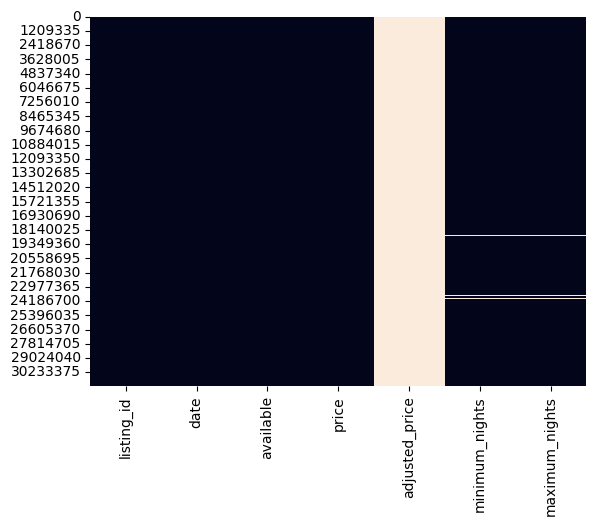

In [45]:
import seaborn as sns
# Plot to see null values in our data
sns.heatmap(calendar.isnull(), cbar=False)

In [46]:
# Check for missing values in the calendar data
missing = calendar.isna().sum()
missing_percent = (missing / len(calendar)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

adjusted_price    99.911623
minimum_nights     0.104784
maximum_nights     0.104784
dtype: float64


In [47]:
# Fill NaN values in 'adjusted_price' with 'price'
calendar["adjusted_price"] = calendar["adjusted_price"].fillna(calendar["price"])

In [48]:
# Check for missing values in the calendar data
missing = calendar.isna().sum()
missing_percent = (missing / len(calendar)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

minimum_nights    0.104784
maximum_nights    0.104784
dtype: float64


In [49]:
enriched_listings = enriched_listings.rename(columns={"id": "listing_id"})

In [52]:
# Merge listing info into calendar
calendar = calendar.merge(
    enriched_listings[["listing_id", "minimum_nights_capped", "maximum_nights"]],
    on="listing_id",
    how="left",
    suffixes=("", "_listing")
)

# Fill missing calendar values with listing info
calendar["minimum_nights"] = calendar["minimum_nights"].fillna(calendar["minimum_nights_capped"])
calendar["maximum_nights"] = calendar["maximum_nights"].fillna(calendar["maximum_nights_listing"])

# Drop helper columns
calendar = calendar.drop(columns=["minimum_nights_capped", "maximum_nights_listing"])

# Fallback to mode if still missing
calendar["minimum_nights"] = calendar["minimum_nights"].fillna(calendar["minimum_nights"].mode()[0])
calendar["maximum_nights"] = calendar["maximum_nights"].fillna(calendar["maximum_nights"].mode()[0])

In [53]:
# save the cleaned calendar data to a new CSV file
calendar.to_csv("calendar_cleaned.csv", index=False)

___

## Price Exploration

In [54]:
# Print the price for a specific listing id (3109)
print("Price for listing id 3109:", enriched_listings.loc[enriched_listings["listing_id"] == 3109, "price"].values[0])

Price for listing id 3109: 100.0


In [55]:
# Calculate and print quantiles for the price column
percentiles = [0.5, 0.75, 0.9, 0.97, 0.99, 1.0]
print(enriched_listings["price"].quantile(percentiles))

0.50      148.00
0.75      248.00
0.90      428.00
0.97      855.00
0.99     1699.87
1.00    30400.00
Name: price, dtype: float64


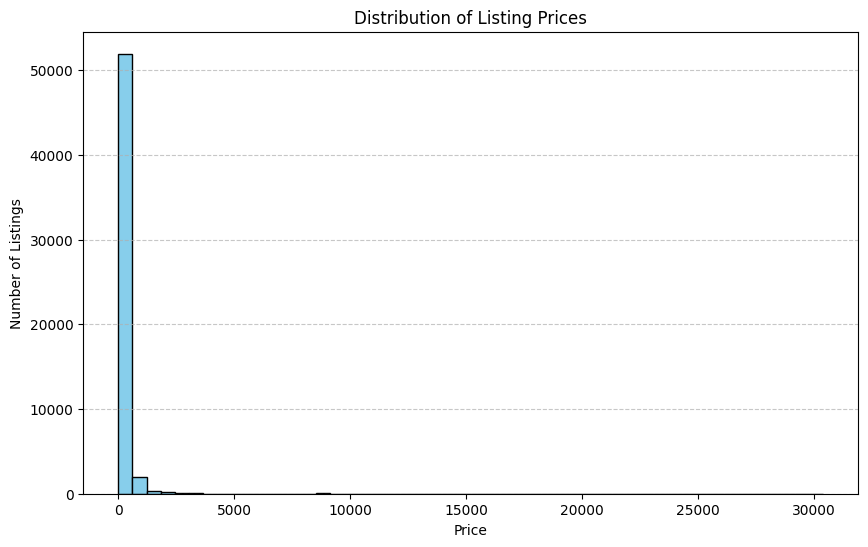

In [56]:
# Plot the distribution of listing prices
plt.figure(figsize=(10, 6))
plt.hist(enriched_listings["price"].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Listing Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [57]:
# Clean adjusted_price to float before finding max
calendar["adjusted_price_clean"] = (
    calendar["adjusted_price"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Show the highest price for each listing_id in the cleaned calendar
max_prices = calendar.groupby("listing_id")["adjusted_price_clean"].max().reset_index()
max_prices = max_prices.sort_values(by="adjusted_price_clean", ascending=False)
print(max_prices.head())

                listing_id  adjusted_price_clean
44937   859979055323328541              145285.0
23555             35154314               90000.0
24870             36897552               50000.0
60558  1069639453928699561               38000.0
6711               7447891               30000.0


In [58]:
percentiles = [0.5, 0.75, 0.9, 0.97, 0.99, 1.0]
print(calendar["adjusted_price_clean"].quantile(percentiles))

0.50       140.0
0.75       250.0
0.90       500.0
0.97      1000.0
0.99      3000.0
1.00    145285.0
Name: adjusted_price_clean, dtype: float64


Based on this, we have later in Power BI capped the price to not skew the average price distribution at 1k USD.

___

## Add attractions table

Source: https://data.mendeley.com/datasets/vh4g4g2322/1

In [61]:
import pandas as pd

file_path = "/Users/franziskameyndt/Desktop/Airbnb Projekt/Attractions.csv"

# Fix: set the delimiter to semicolon
df = pd.read_csv(
    file_path,
    sep=';', # Use semicolon as the delimiter
    usecols=['id', 'category', 'subCategory', 'name', 'lat', 'lng']
)

In [62]:
#%pip install geopy

In [63]:
from geopy.distance import geodesic

In [64]:
# Define attractions DataFrame
attractions = df

In [65]:
# Copy enriched listings to avoid modifying the original DataFrame
listings = enriched_listings.copy()

In [67]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# Prepare coordinates
listings_coords = np.radians(listings[['latitude', 'longitude']].values)
attractions_coords = np.radians(attractions[['lat', 'lng']].values)

# Build BallTree on attractions
tree = BallTree(attractions_coords, metric='haversine')

# Define radius in radians (1 km)
radius_km = 1
radius_rad = radius_km / 6371.0

# Query for each listing
indices = tree.query_radius(listings_coords, r=radius_rad)

# Collect matches
matches = []
for listing_idx, attraction_indices in enumerate(indices):
    for attraction_idx in attraction_indices:
        distance_km = 6371.0 * np.linalg.norm(
            listings_coords[listing_idx] - attractions_coords[attraction_idx]
        )
        matches.append({
            'listing_id': listings.iloc[listing_idx]['listing_id'],
            'attraction_id': attractions.iloc[attraction_idx]['id'],
            'attraction_name': attractions.iloc[attraction_idx]['name'],
            'attraction_category': attractions.iloc[attraction_idx]['category'],
            'attraction_subCategory': attractions.iloc[attraction_idx]['subCategory'],
            'latitude': attractions.iloc[attraction_idx]['lat'],
            'longitude': attractions.iloc[attraction_idx]['lng'],
            'distance_km': round(distance_km, 3)
        })

# Convert to DataFrame
nearby_attractions = pd.DataFrame(matches)

In [68]:
# Save the nearby attractions to a CSV file
nearby_attractions.to_csv("nearby_attractions.csv", index=False)

In [69]:
# Display the first few rows of the nearby attractions
print(nearby_attractions["distance_km"].head())

0    0.411
1    0.991
2    0.668
3    0.222
4    1.288
Name: distance_km, dtype: float64


____

## Amenitites Count

In [70]:
# Make data "amenities" sense
from collections import Counter
import re
 
# Drop missing values
amenities_series = enriched_listings['amenities'].dropna()
 
# Split by comma, clean up each word, and flatten
all_words = [
    re.sub(r'[^a-zA-Z0-9\s]', '', word).strip().lower()
    for line in amenities_series
    for word in line.split(',')]
 
# Count word frequencies
word_counts = Counter(all_words)  
 
#Show top 50 most common words
for word, count in word_counts.most_common(50):
   print(f"{word}: {count}")

kitchen: 71994
wifi: 69861
hot water: 59913
smoke alarm: 59478
hair dryer: 56255
essentials: 56250
dishes and silverware: 54205
bed linens: 53253
cooking basics: 53041
iron: 51655
hangers: 50960
refrigerator: 49705
washer: 48028
heating: 43006
microwave: 42775
tv: 40795
shampoo: 40147
hot water kettle: 39196
dedicated workspace: 36018
cleaning products: 35509
wine glasses: 34747
shower gel: 32136
baking sheet: 32129
toaster: 32128
dining table: 31876
freezer: 31767
oven: 31112
dishwasher: 30420
coffee maker: 26256
drying rack for clothing: 26000
elevator: 24923
body soap: 24618
coffee: 24589
self checkin: 22817
extra pillows and blankets: 22203
roomdarkening shades: 21346
long term stays allowed: 20973
carbon monoxide alarm: 20883
host greets you: 18434
stove: 18194
books and reading material: 17564
lockbox: 17119
bathtub: 17032
portable fans: 16000
laundromat nearby: 15219
clothing storage: 14186
central heating: 13838
first aid kit: 13791
luggage dropoff allowed: 12780
private entran